<a href="https://colab.research.google.com/github/nataliagdorado/MachineLearningMenstrualIrregularities/blob/main/Notebook_1_DataQualityAssesmentGraphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving MentrualSetFinalCSV.csv to MentrualSetFinalCSV.csv


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]
print("Archivo detectado:", filename)

df = pd.read_csv(filename, sep=';')  # <-- ¡IMPORTANTE!
print("Dataset cargado con shape:", df.shape)

display(df.head())
df.info()


Archivo detectado: MentrualSetFinalCSV.csv
Dataset cargado con shape: (10000, 17)


,avg_bleeding_days,Oligomenorrhea,Polymenorrhea,Menorrhagia,Amenorrhea,age,bmi,tracking_duration_months,pain_score,avg_cycle_length,cycle_length_variation,bleeding_volume_score,intermenstrual_episodes,cycle_variation_coeff,pattern_disruption_score,life_stage,duration_abnormality_flag
0,5,1.0,0.0,0.0,0.0,51,19.4,22,2,27.783958,59.154302,2,1,0.000000,20.000000,perimenopausal,0
1,4,1.0,0.0,0.0,0.0,41,22.4,15,0,27.783958,26.434149,2,0,48.610705,10.000000,reproductive,0
2,4,1.0,0.0,0.0,0.0,27,27.0,12,1,38.211179,39.886876,2,0,103.660141,92.928112,reproductive,0
3,4,0.0,1.0,0.0,0.0,20,22.4,14,1,27.783958,23.175502,2,0,121.021249,100.000000,reproductive,0
4,4,0.0,0.0,0.0,1.0,33,22.8,11,3,27.783958,0.000000,2,0,0.000000,10.000000,reproductive,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   avg_bleeding_days          10000 non-null  int64  
 1   Oligomenorrhea             10000 non-null  float64
 2   Polymenorrhea              10000 non-null  float64
 3   Menorrhagia                10000 non-null  float64
 4   Amenorrhea                 10000 non-null  float64
 5   age                        10000 non-null  int64  
 6   bmi                        10000 non-null  float64
 7   tracking_duration_months   10000 non-null  int64  
 8   pain_score                 10000 non-null  int64  
 9   avg_cycle_length           10000 non-null  float64
 10  cycle_length_variation     10000 non-null  float64
 11  bleeding_volume_score      10000 non-null  int64  
 12  intermenstrual_episodes    10000 non-null  int64  
 13  cycle_variation_coeff      10000 non-null  floa

Columnas numéricas: ['avg_bleeding_days', 'Oligomenorrhea', 'Polymenorrhea', 'Menorrhagia', 'Amenorrhea', 'age', 'bmi', 'tracking_duration_months', 'pain_score', 'avg_cycle_length', 'cycle_length_variation', 'bleeding_volume_score', 'intermenstrual_episodes', 'cycle_variation_coeff', 'pattern_disruption_score', 'duration_abnormality_flag']


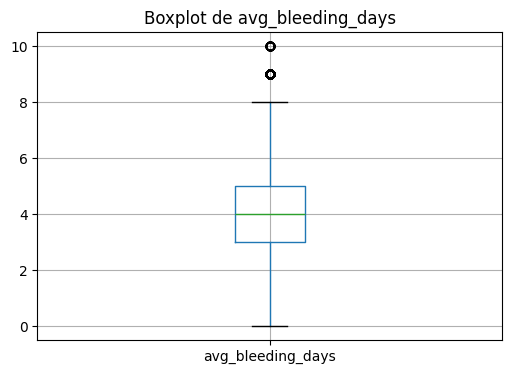

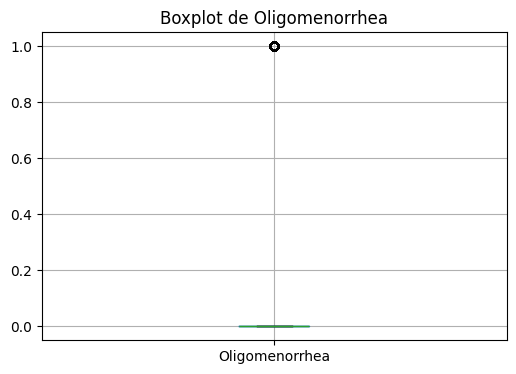

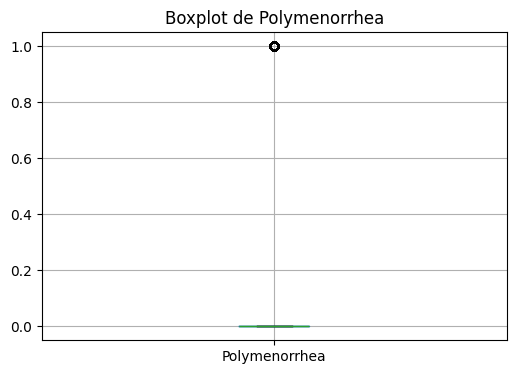

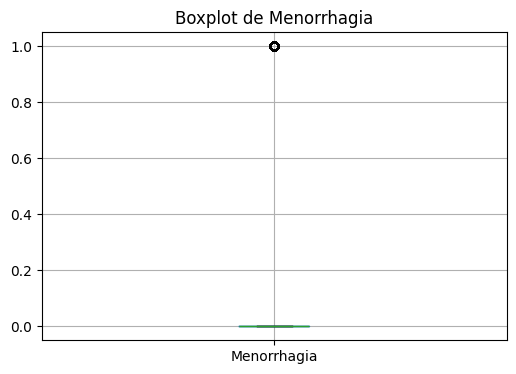

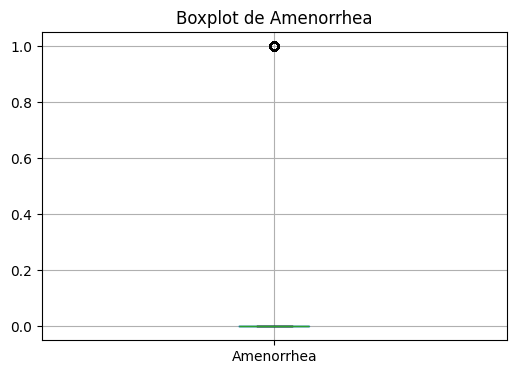

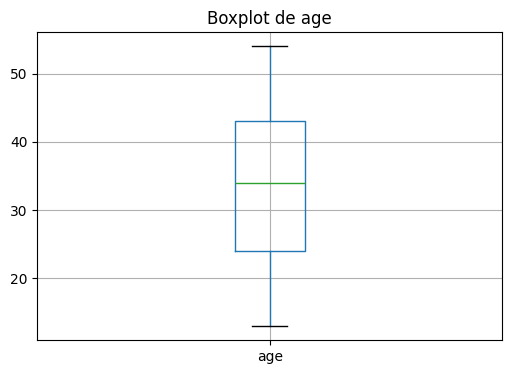

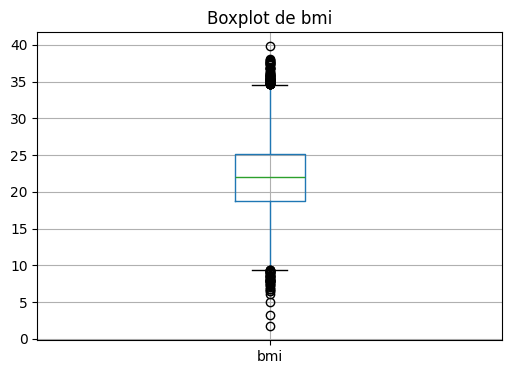

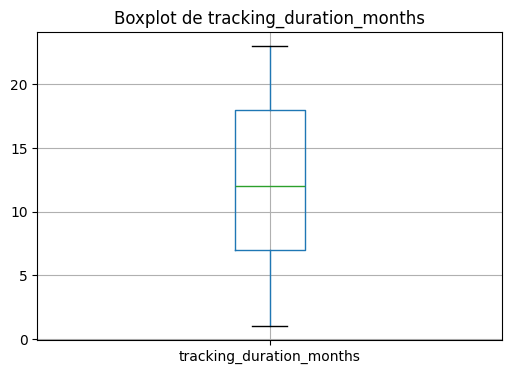

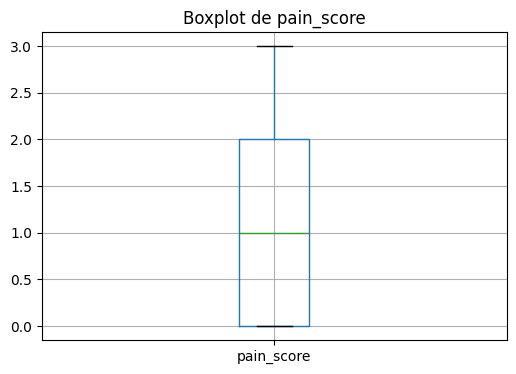

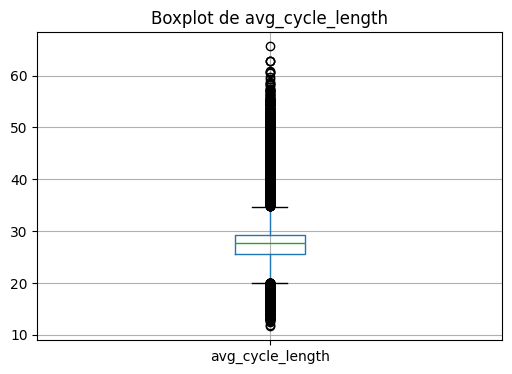

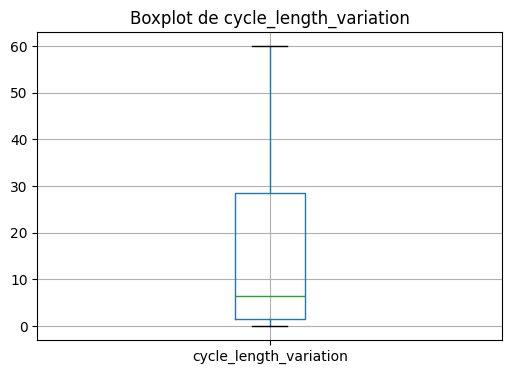

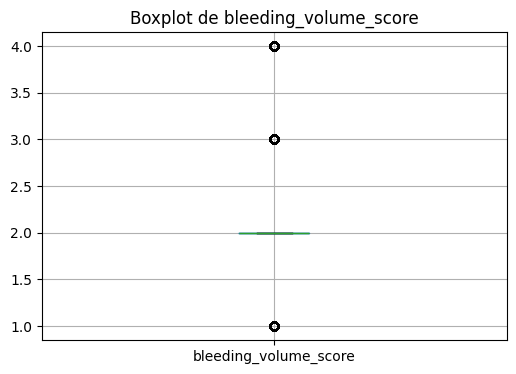

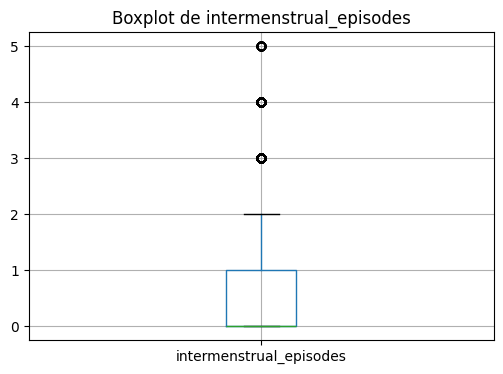

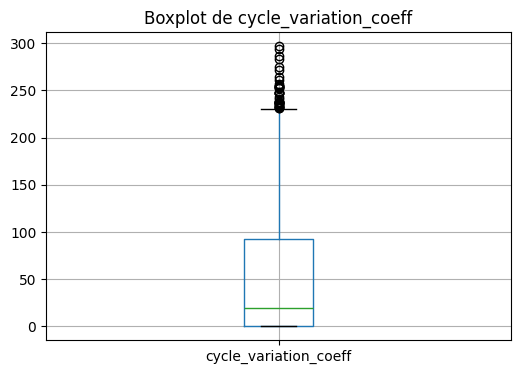

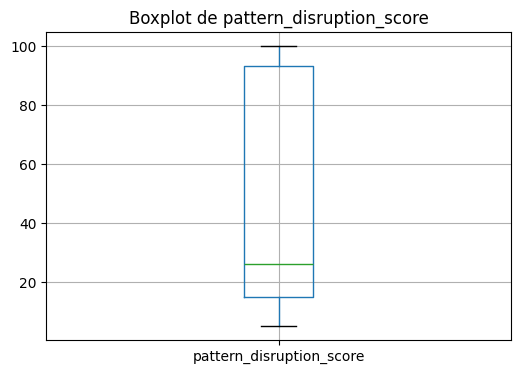

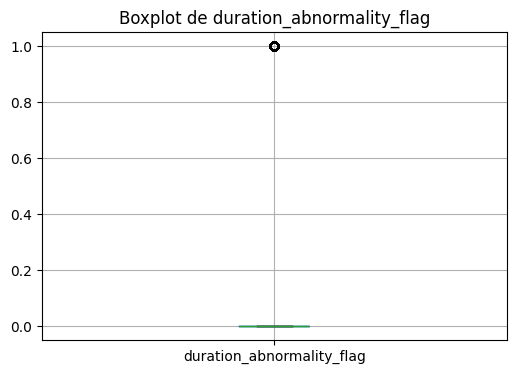

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Columnas numéricas:", list(numeric_cols))

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=[col])
    plt.title(f'Boxplot de {col}')
    plt.show()


['avg_bleeding_days', 'Oligomenorrhea', 'Polymenorrhea', 'Menorrhagia', 'Amenorrhea', 'age', 'bmi', 'tracking_duration_months', 'pain_score', 'avg_cycle_length', 'cycle_length_variation', 'bleeding_volume_score', 'intermenstrual_episodes', 'cycle_variation_coeff', 'pattern_disruption_score', 'life_stage', 'duration_abnormality_flag']


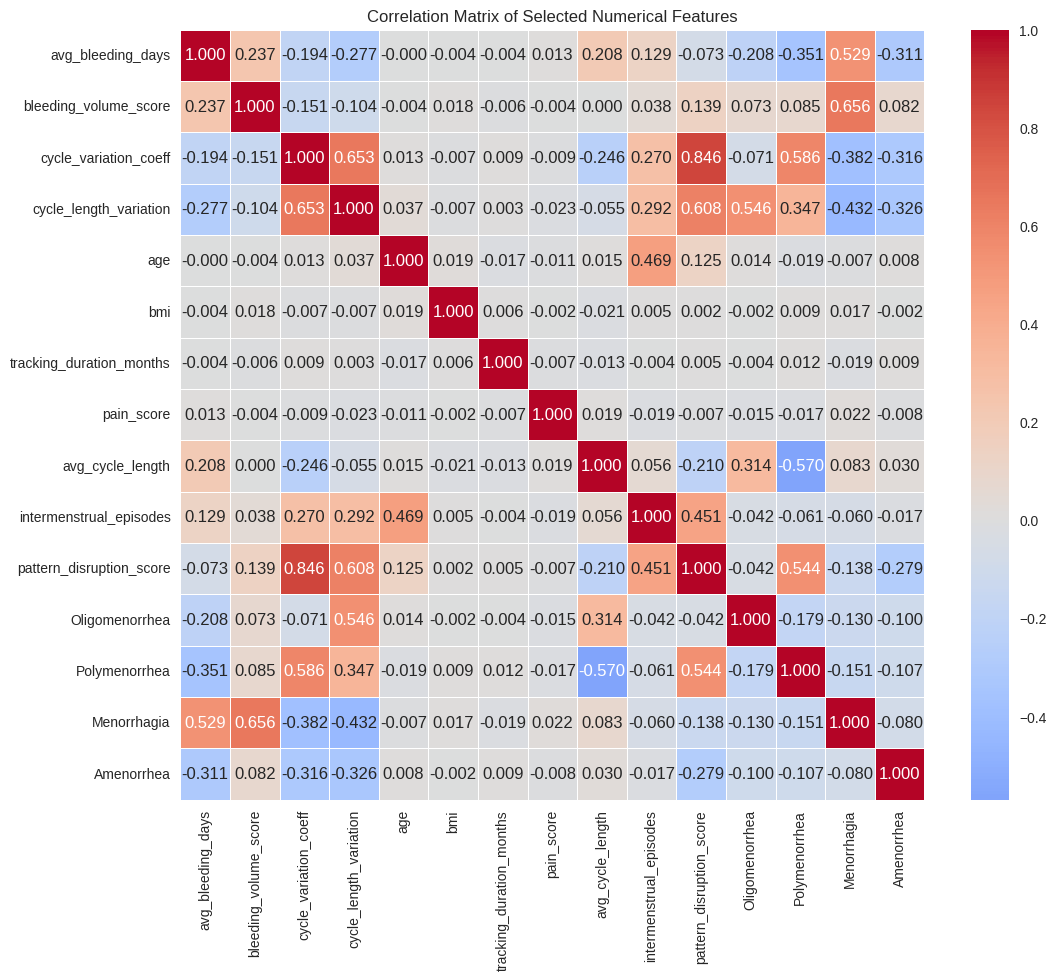

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(df.columns.tolist())
numeric_cols = [#columnas numericas que se veran en la scatter matrix
    "avg_bleeding_days",
    "bleeding_volume_score",
    "cycle_variation_coeff",
    "cycle_length_variation",
    "age",
    "bmi",
    "tracking_duration_months",
    "pain_score",
    "avg_cycle_length",
    "intermenstrual_episodes",
    "pattern_disruption_score",
    "Oligomenorrhea",
    "Polymenorrhea",
    "Menorrhagia",
    "Amenorrhea"
]

df_plot = df[numeric_cols]#guarda solo las columnas numericas indicadas anteriormente
corr_matrix = df_plot.corr(method="spearman")
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,#muestra los valores numericos
    fmt=".3f",#solo muestra 3 decimales de cada valor
    linewidths=0.5
)
plt.title("Correlation Matrix of Selected Numerical Features")
plt.show()



['avg_bleeding_days', 'Oligomenorrhea', 'Polymenorrhea', 'Menorrhagia', 'Amenorrhea', 'age', 'bmi', 'tracking_duration_months', 'pain_score', 'avg_cycle_length', 'cycle_length_variation', 'bleeding_volume_score', 'intermenstrual_episodes', 'cycle_variation_coeff', 'pattern_disruption_score', 'life_stage', 'duration_abnormality_flag']


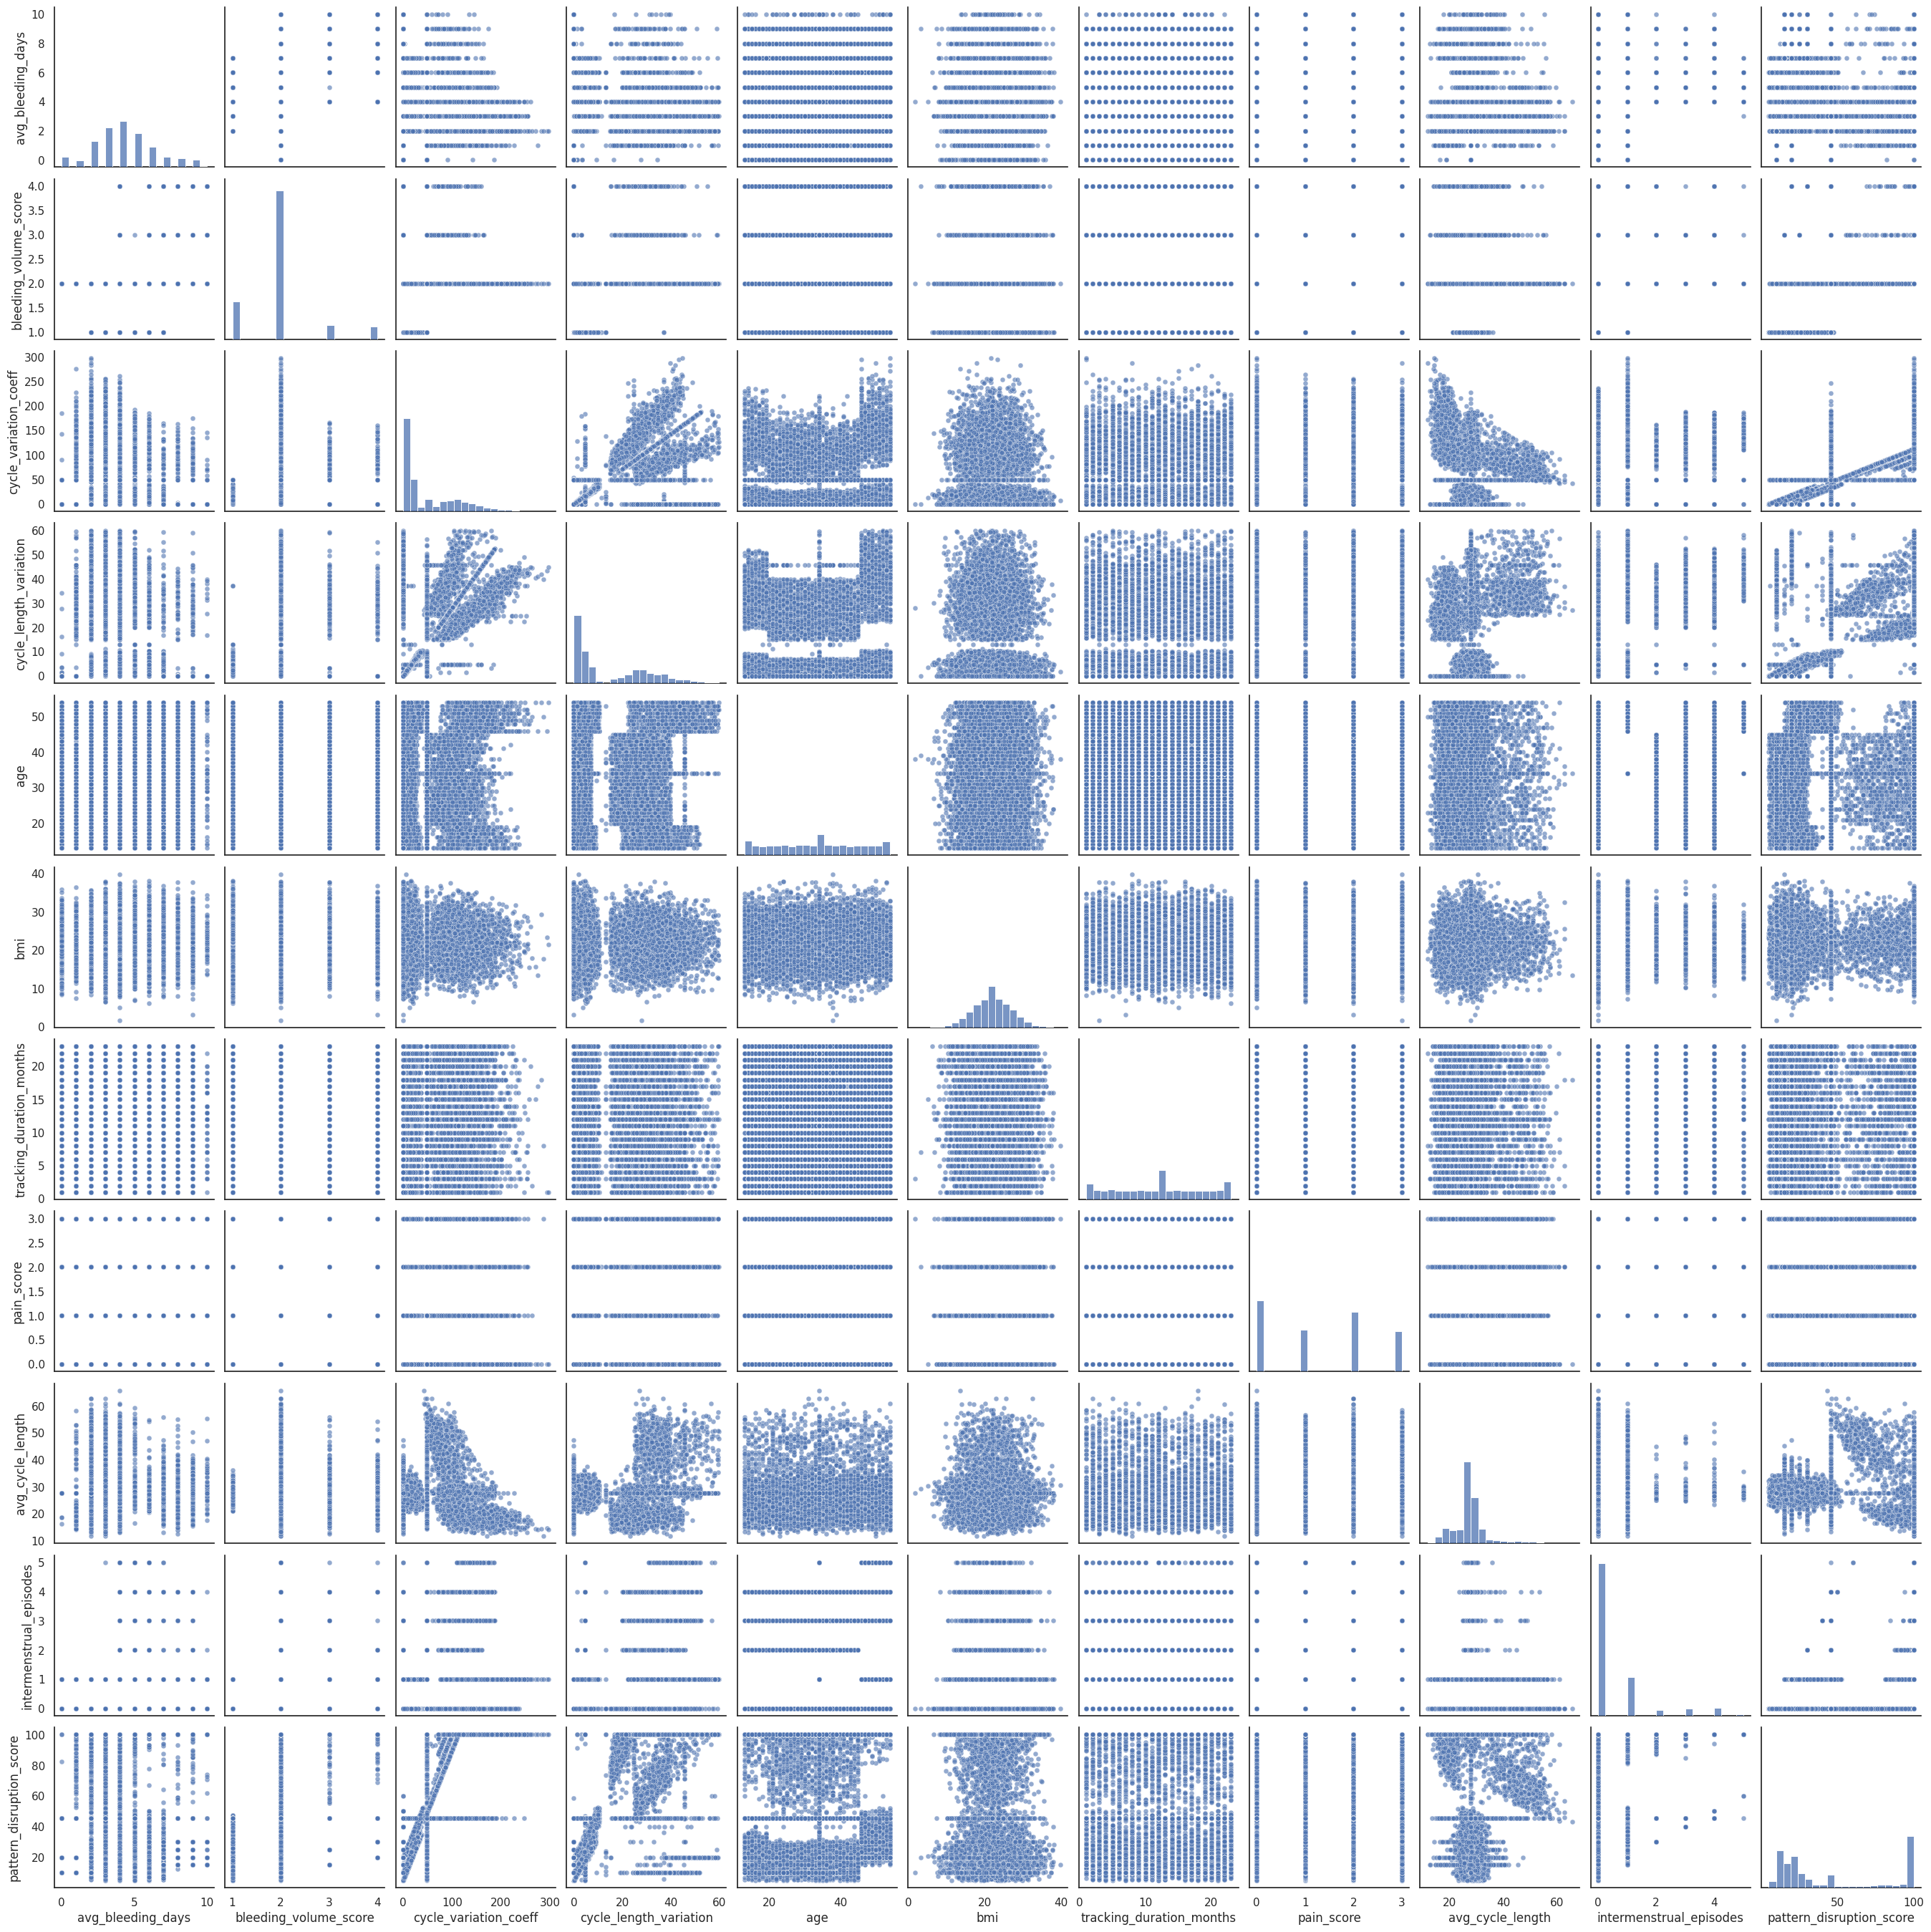

In [ ]:


import seaborn as sns #libreria de visualizacion
import matplotlib.pyplot as plt

print(df.columns.tolist()) #ver los nombres exactos de las columnas


numeric_cols = [#columnas numericas que se veran en la scatter matrix
    "avg_bleeding_days",
    "bleeding_volume_score",
    "cycle_variation_coeff",
    "cycle_length_variation",
    "age",
    "bmi",
    "tracking_duration_months",
    "pain_score",
    "avg_cycle_length",
    "intermenstrual_episodes",
    "pattern_disruption_score",


]

df_plot = df[numeric_cols]#guarda solo las columnas numericas indicadas anteriormente

sns.set(style="white")# "estilo" de la grafica

sns.pairplot(
    df_plot, #matriz de graficos
    diag_kind="hist", #histogramas en la diagonal
    plot_kws={"alpha": 0.6, "s": 25},#transparencia y tamaño de los pts respectivamente
    diag_kws={"bins": 20}#numero de "barras" del histograma
)

plt.show()


['avg_bleeding_days', 'Oligomenorrhea', 'Polymenorrhea', 'Menorrhagia', 'Amenorrhea', 'age', 'bmi', 'tracking_duration_months', 'pain_score', 'avg_cycle_length', 'cycle_length_variation', 'bleeding_volume_score', 'intermenstrual_episodes', 'cycle_variation_coeff', 'pattern_disruption_score', 'life_stage', 'duration_abnormality_flag']


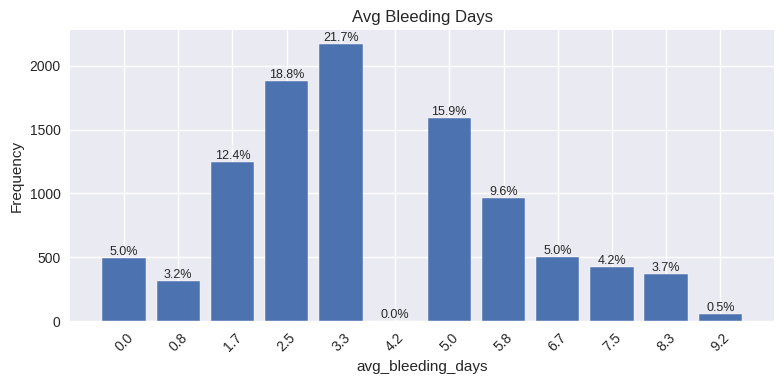

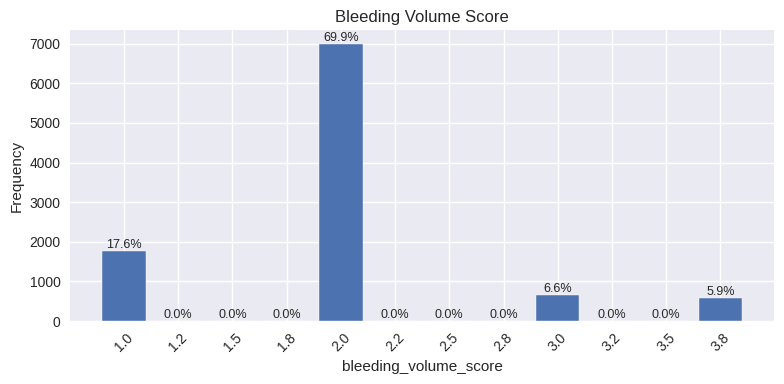

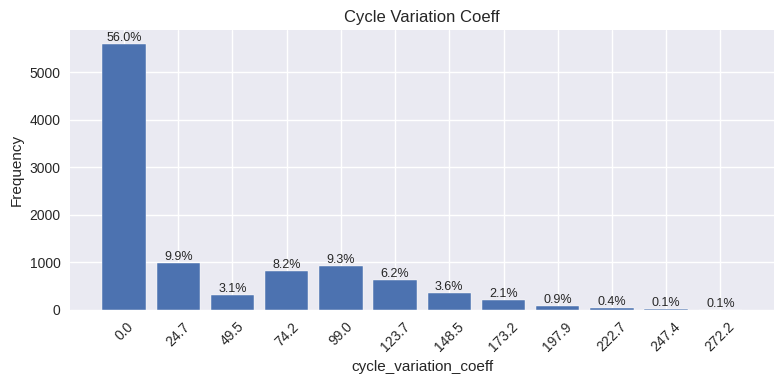

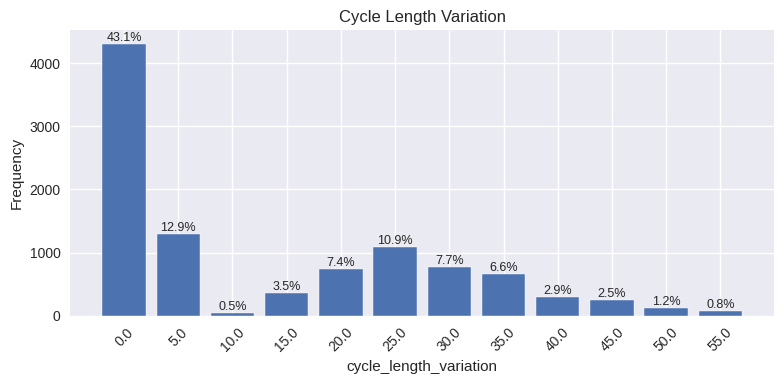

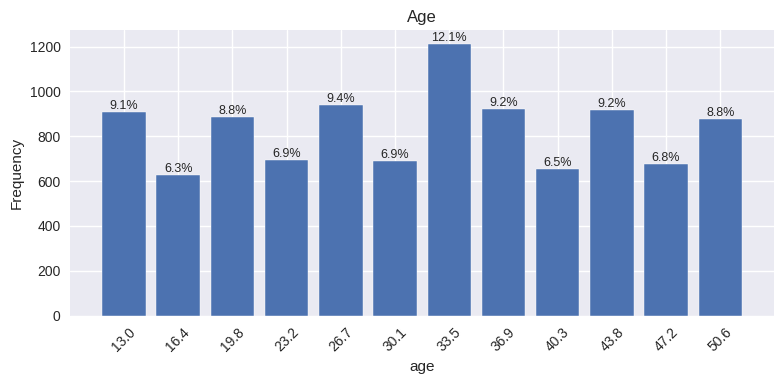

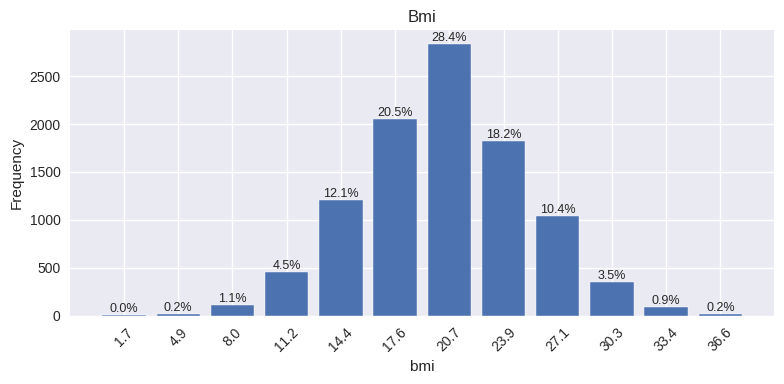

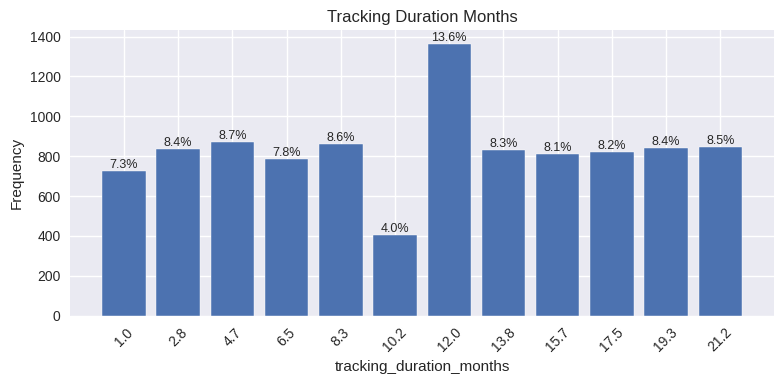

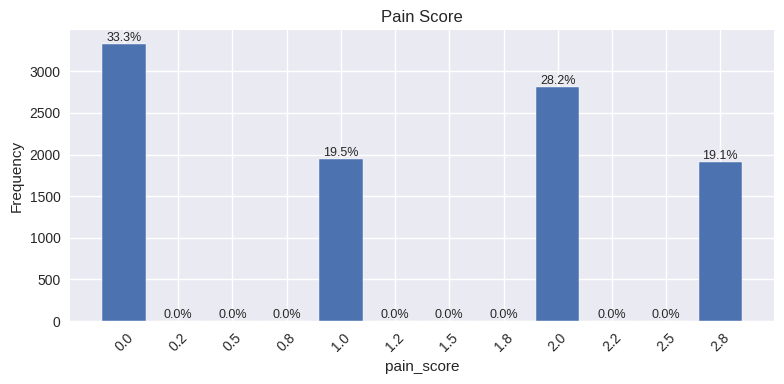

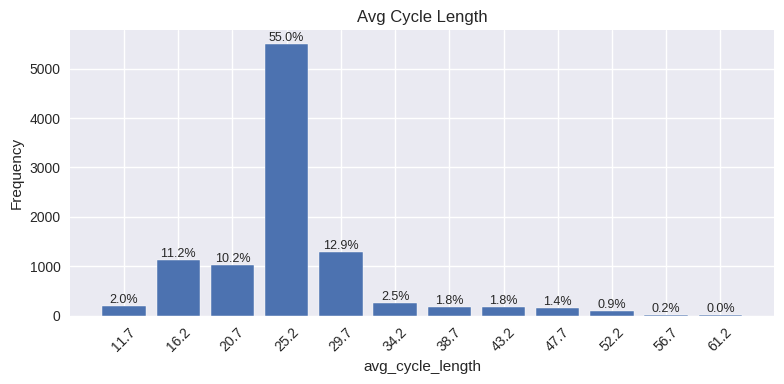

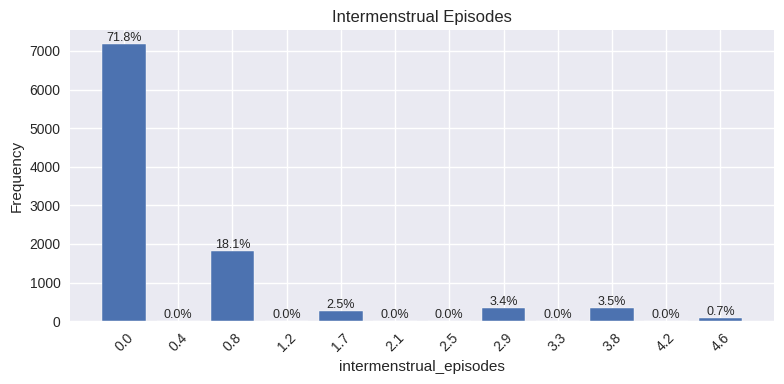

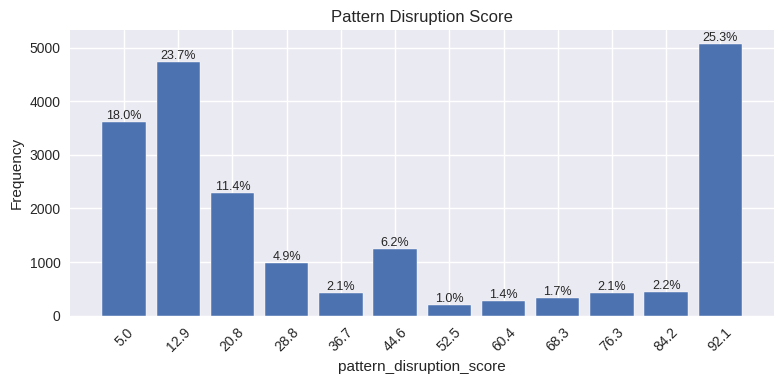

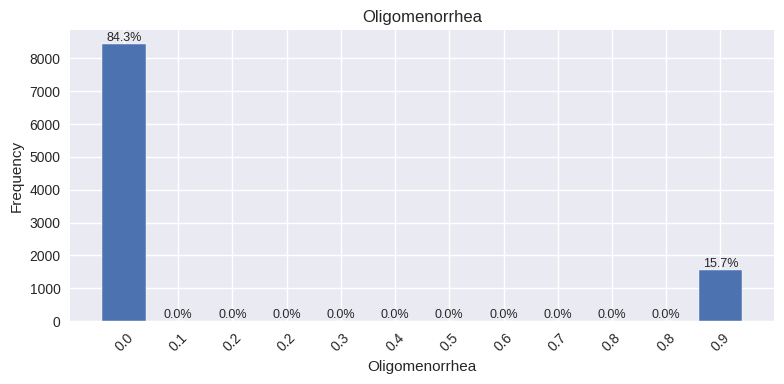

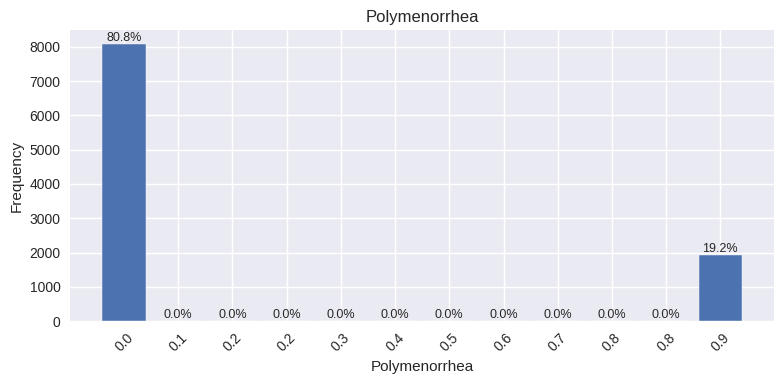

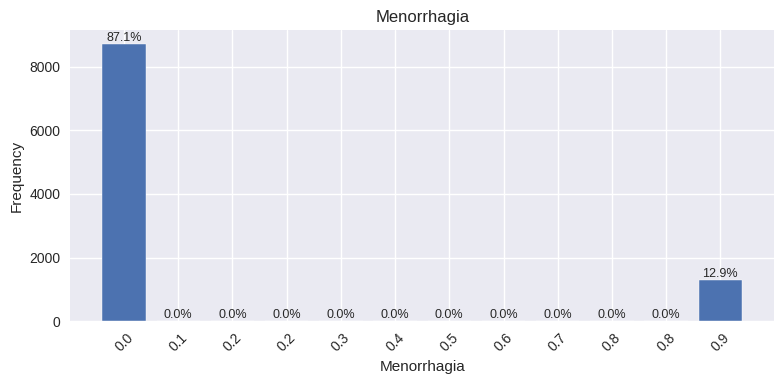

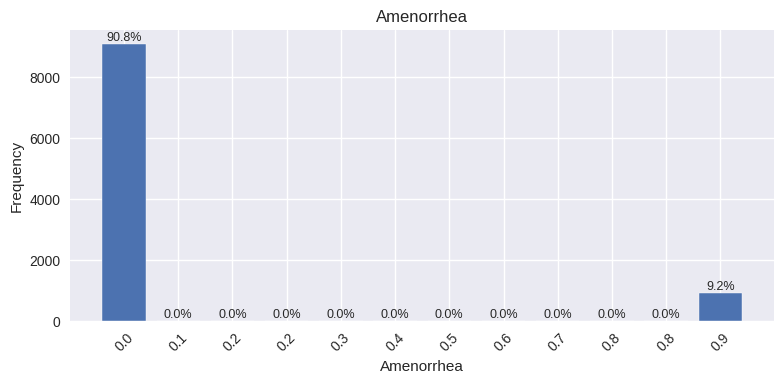

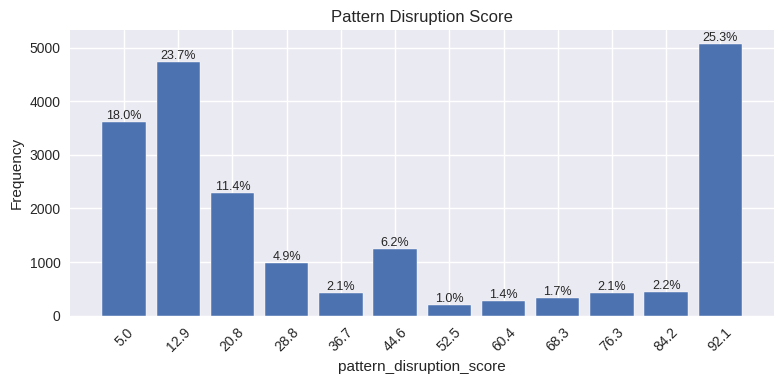

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(df.columns.tolist())
numeric_cols = [#columnas numericas que se veran en la scatter matrix
    "avg_bleeding_days",
    "bleeding_volume_score",
    "cycle_variation_coeff",
    "cycle_length_variation",
    "age",
    "bmi",
    "tracking_duration_months",
    "pain_score",
    "avg_cycle_length",
    "intermenstrual_episodes",
    "pattern_disruption_score",
    "Oligomenorrhea",
    "Polymenorrhea",
    "Menorrhagia",
    "Amenorrhea"
]

df_plot = df[numeric_cols]#guarda solo las columnas numericas indicadas anteriormente


plt.style.use("seaborn-v0_8")

for col in df_plot.columns:
    data = df_plot[col].dropna()

    counts, bins = np.histogram(data, bins=12)
    percentages = counts / counts.sum() * 100

    plt.figure(figsize=(8, 4))
    bars = plt.bar(range(len(counts)), counts)

    for bar, pct in zip(bars, percentages):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.title(col.replace("_", " ").title())
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(
        range(len(counts)),
        [f"{bins[i]:.1f}" for i in range(len(bins) - 1)],
        rotation=45
    )

    plt.tight_layout()
    plt.show()
